In [43]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

from sklearn.metrics import r2_score, root_mean_squared_error

from pickle import dump, load


In [12]:
housing_data = fetch_california_housing()
housing_data_df = pd.DataFrame(housing_data.data, columns =housing_data.feature_names )
housing_data_df["target"] = housing_data.target

In [13]:
housing_data_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [14]:
housing_data_df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [15]:
housing_data_df.shape

(20640, 9)

In [16]:
housing_data_df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object

In [20]:
housing_data_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [21]:
housing_data_df.nunique()

MedInc        12928
HouseAge         52
AveRooms      19392
AveBedrms     14233
Population     3888
AveOccup      18841
Latitude        862
Longitude       844
target         3842
dtype: int64

In [23]:
X = housing_data_df.drop("target", axis = 1)
y = housing_data_df["target"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,
                                                    random_state=23,
                                                    shuffle=True)

In [25]:
X_train.shape, y_train.shape

((16512, 8), (16512,))

In [26]:
X_test.shape, y_test.shape

((4128, 8), (4128,))

In [76]:
linear_model = LinearRegression()
l2_model = Ridge(alpha=1.0)
l1_model = Lasso(alpha=0.1)
elastic_model = ElasticNet(alpha=0.1,l1_ratio=0.5)

In [77]:
linear_model.fit(X_train,y_train)
l2_model.fit(X_train,y_train)
l1_model.fit(X_train,y_train)
elastic_model.fit(X_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [78]:
linear_model.coef_

array([ 4.36653915e-01,  9.14855202e-03, -1.09385284e-01,  6.16678441e-01,
       -3.19921086e-06, -8.60599049e-03, -4.19645937e-01, -4.31454700e-01])

In [79]:
l2_model.coef_

array([ 4.36534064e-01,  9.15074712e-03, -1.09156681e-01,  6.15504235e-01,
       -3.18941141e-06, -8.60812657e-03, -4.19626695e-01, -4.31417980e-01])

In [36]:
l1_model.coef_

array([ 3.89385940e-01,  1.50360595e-02, -0.00000000e+00,  0.00000000e+00,
        1.92776489e-05, -4.98501919e-03, -1.14001126e-01, -9.72486161e-02])

In [37]:
elastic_model.coef_

array([ 3.82784615e-01,  1.28675263e-02, -0.00000000e+00,  0.00000000e+00,
        1.08741154e-05, -7.32077199e-03, -2.41397606e-01, -2.33461798e-01])

In [41]:
lm_coef_df = pd.DataFrame({"Features" : housing_data.feature_names,"Co-efficients" : linear_model.coef_})
l2_coef_df = pd.DataFrame({"Features" : housing_data.feature_names,"Co-efficients" : l2_model.coef_})
l1_coef_df = pd.DataFrame({"Features" : housing_data.feature_names,"Co-efficients" : l1_model.coef_})
el_coef_df = pd.DataFrame({"Features" : housing_data.feature_names,"Co-efficients" : elastic_model.coef_})

In [52]:
y_pred_train_lm = linear_model.predict(X_train)
y_pred_train_l1 = l1_model.predict(X_train)
y_pred_train_l2 = l2_model.predict(X_train)
y_pred_train_el = elastic_model.predict(X_train)

In [53]:
print("linear model r2 score:", round(r2_score(y_train,y_pred_train_lm),4))
print("l1 model r2 score:", round(r2_score(y_train,y_pred_train_l1),4))
print("l2 model r2 score:", round(r2_score(y_train,y_pred_train_l2),4))
print("elastic net r2 score:", round(r2_score(y_train,y_pred_train_el),4))

linear model r2 score: 0.6023
l1 model r2 score: 0.5415
l2 model r2 score: 0.6023
elastic net r2 score: 0.5729


In [58]:
print("RMSE Linear model :" ,round(root_mean_squared_error(y_train,y_pred_train_lm),4))
print("RMSE Lasso model :" ,round(root_mean_squared_error(y_train,y_pred_train_l1),4))
print("RMSE Ridge model :" ,round(root_mean_squared_error(y_train,y_pred_train_l2),4))
print("RMSE Elastic Net model :" ,round(root_mean_squared_error(y_train,y_pred_train_el),4))

RMSE Linear model : 0.7261
RMSE Lasso model : 0.7797
RMSE Ridge model : 0.7261
RMSE Elastic Net model : 0.7525


In [59]:
import matplotlib.pyplot as plt 

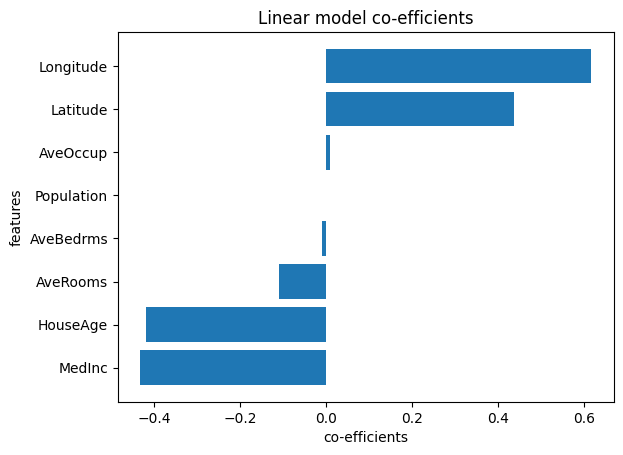

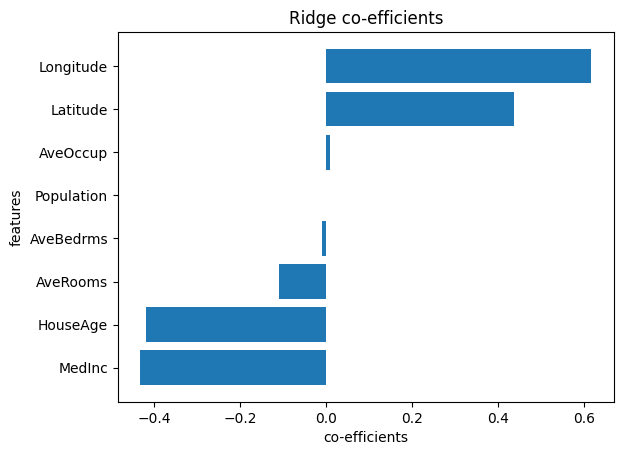

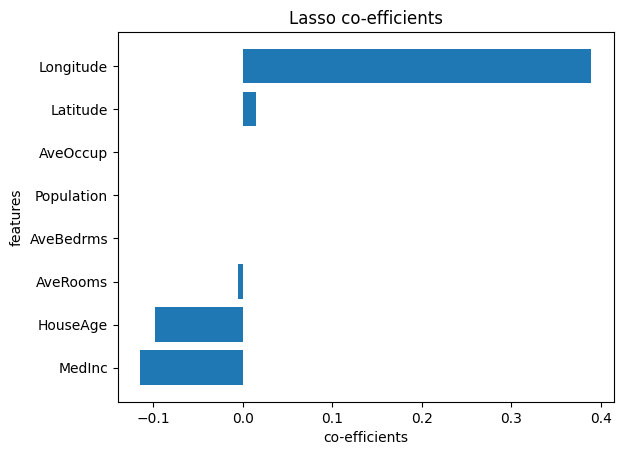

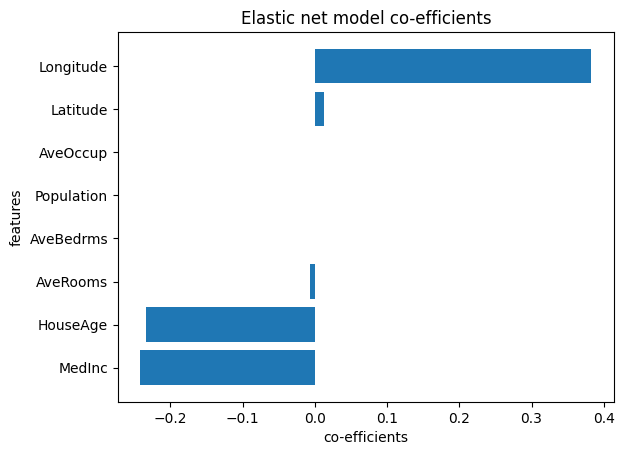

In [67]:
plt.barh( lm_coef_df["Features"],lm_coef_df["Co-efficients"].sort_values())
plt.title("Linear model co-efficients")
plt.xlabel("co-efficients")
plt.ylabel("features")
plt.show()

plt.barh( l2_coef_df["Features"],l2_coef_df["Co-efficients"].sort_values())
plt.title("Ridge co-efficients")
plt.xlabel("co-efficients")
plt.ylabel("features")
plt.show()

plt.barh( l1_coef_df["Features"],l1_coef_df["Co-efficients"].sort_values())
plt.title("Lasso co-efficients")
plt.xlabel("co-efficients")
plt.ylabel("features")
plt.show()

plt.barh( el_coef_df["Features"],el_coef_df["Co-efficients"].sort_values())
plt.title("Elastic net model co-efficients")
plt.xlabel("co-efficients")
plt.ylabel("features")
plt.show()

In [81]:
dump(l1_model,file=open(file="Lasso_model.pkl", mode="wb"))

In [82]:
lasso_intel_file = load(file=open(file="Lasso_model.pkl", mode="rb"))

In [85]:
y_pred_test_l1 = lasso_intel_file.predict(X_test)

In [87]:
print("test data r2 score:", round(r2_score(y_test,y_pred_test_l1),4))
print("test data RMSE :" ,round(root_mean_squared_error(y_test,y_pred_test_l1),4))

test data r2 score: 0.5576
test data RMSE : 0.7742
